In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# The star of the show!
import bayesflow as bf

from bayesflow.simulation import Prior, Simulator, GenerativeModel

np.set_printoptions(suppress=True)


C:\Users\Gerald Wong\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\bayesflow\trainers.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


# Posterior Estimation for Simple Autoregressive Model

In this notebook, we look at a simple example of using BayesFlow to perform posterior parameter estimation for a stochastic time-series model. In particular, we use the [Ricker population model](https://en.wikipedia.org/wiki/Ricker_model) -- a non-linear autoregressive model -- as our model of interest, and we use BayesFlow to demonstrate that parameters of the model can be recovered from summary statistics learned from transformer networks. 

The Ricker model is defined as:

\begin{align}
    x_t &\sim \textrm{Poisson}(\rho N_t), \\
    \xi_t &\sim \mathcal{N}(0, \sigma^2), \\
    N_{t+1} &= r N_t \exp{(-N_t + \xi_t)},
\end{align}

where 

* $t = 1, ..., T$ is the time step;
* $N_t$ is the expected number of individuals at time $t$;
* $x_t$ is the actual number of individuals at time $t$;
* $r$ is the population growth rate;
* $\rho$ is a scaling parameter; 
* $\xi_t$ is a Gaussian random noise. 

## Priors

We sample the priors for three parameters of interest: the growth rate $r$, the scaling parameter $\rho$, and the variance of the noise parameter $\sigma$. Our posterior estimates would seek to recover these three parameters:

\begin{align}
    r &\sim \mathcal{U}(1, 10), \\
    \rho &\sim \mathcal{U}(0, 10), \\
    \sigma &\sim \mathcal{U}(0.01, 1)
\end{align}

In [3]:
param_names = [r'$r$', r'$\rho$', r'$\sigma$']

In [4]:
def prior_fun(rng=None):
    """
    Function that samples and bundles all parameters of interest.

    Returns
    -------
    theta   : np.array of shape(3, )
        An array of 3 parameters for the Ricker model, including
        * r     : growth rate
        * rho   : scaling parameter
        * sigma : variance of perturbation noise
    """

    if rng is None:
        rng = np.random.default_rng()

    r = rng.uniform(1., 10.)
    rho = rng.uniform(0., 10.)
    sigma = rng.uniform(0.01, 1)

    theta = np.array([r, rho, sigma])
    return theta

We use BayesFlow's ``prior`` wrapper to inspect our chosen priors.

In [5]:
prior = Prior(prior_fun=prior_fun, param_names=param_names)

In [6]:
prior(batch_size=5)

{'prior_draws': array([[3.60690415, 7.0351608 , 0.12556361],
        [2.89780476, 1.13187538, 0.02177502],
        [8.38735012, 8.97356714, 0.11874978],
        [9.37362343, 7.98765382, 0.71469987],
        [2.40542581, 7.05478599, 0.01425838]]),
 'batchable_context': None,
 'non_batchable_context': None}

### Prior Predictive Check

To see if our priors makes sense -- namely, if they are all sampled within the designed distribution -- we can perform a prior predictive check via visualization.

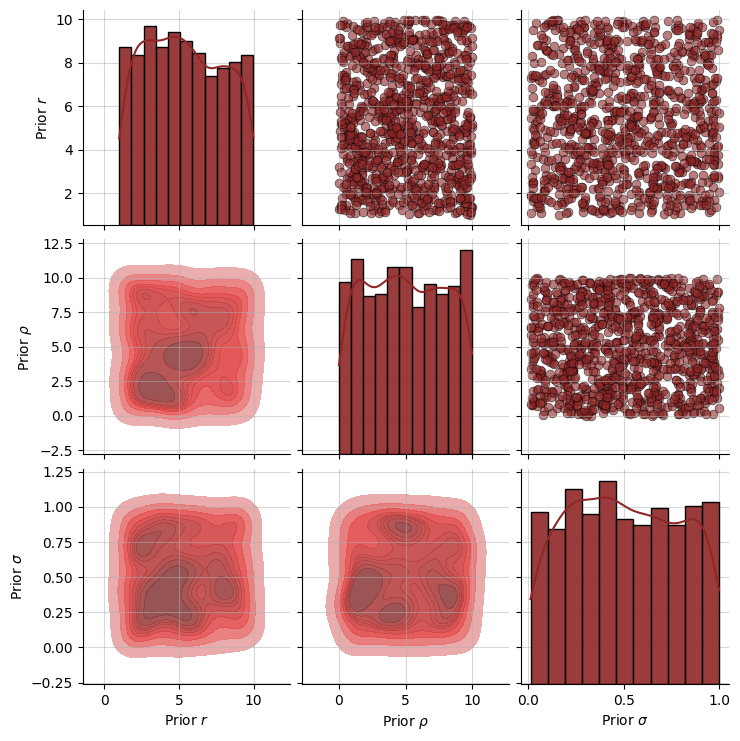

In [7]:
f = prior.plot_prior2d(n_samples=1000)

## Simulator

We implement the definition of the Ricker model in a little ``simulator`` function. Then, we wrap it using BayesFlow's ``Simulator`` wrapper.        

In [8]:
def simulator_fun(theta, n_timesteps=101, rng=None):
    """ 
    Simulator function that implements the Ricker model.

    Parameters
    ----------
    theta   : np.array of shape (3,)
        An array of 3 parameters for the Ricker model, including
        * r     : growth rate
        * rho   : scaling parameter
        * sigma : variance of perturbation noise
    n_timesteps : int
        Number of time steps for the simulation.
    rng         : np.random
        Random number generator. If not specified, default is used.

    Returns
    -------
    x       : np.array of shape (n_timesteps,)
        Simulated population as time-series.
    """

    if rng is None:
        rng = np.random.default_rng()
    
    r, rho, sigma = theta

    # Expected population
    N = 10

    # Estimated population
    x = np.zeros((n_timesteps, 1))

    for t in range(n_timesteps):
        x[t,:] = rng.poisson(rho * N)
        xi = rng.normal(0, sigma)
        N = r * N * np.exp(-N + xi)
    
    return x

In [9]:
simulator = Simulator(simulator_fun=simulator_fun)

## Generative Model

The generative model is the equivalent of a Bayesian joint model:

\begin{equation}
    p(\theta, x) = p(\theta) p(x | \theta), \quad \theta = [r, \rho, \sigma]
\end{equation}

In [10]:
def model_fun():

    theta = prior_fun()
    x = simulator_fun(theta)

    return theta, x

With this generative model, we can simulate the actual population dynamics and visualize it.

<Axes: >

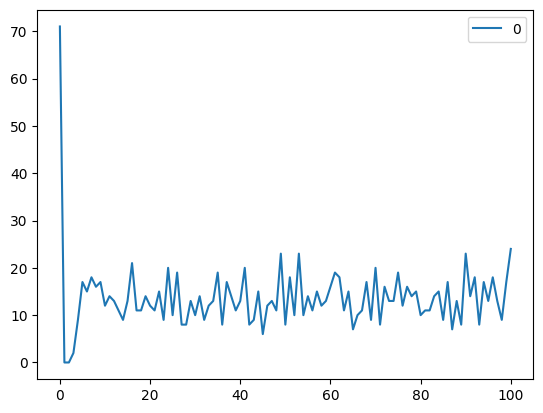

In [11]:
theta, x = model_fun()
sns.lineplot(x)

Meanwhile, we can also obtain a ground truth for examining parameter recovery later.

In [12]:
theta

array([6.55151644, 7.4864428 , 0.13214987])

Once again, we use BayesFlow's ``GenerativeModel`` wrapper, which takes in the wrapped ``prior`` function and the wrapped ``simulator``, for simulating the model in batches.

In [14]:
model = GenerativeModel(prior=prior_fun, simulator=simulator_fun, simulator_is_batched=False)

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 3)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 101, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


In [15]:
sim = model(10)
sim

{'prior_non_batchable_context': None,
 'prior_batchable_context': None,
 'prior_draws': array([[5.43618417, 4.25603417, 0.8294896 ],
        [8.11781154, 3.69013884, 0.13472748],
        [8.4723404 , 7.94541772, 0.96682582],
        [5.61034349, 8.98909418, 0.69182316],
        [8.97773064, 8.26411721, 0.69868984],
        [3.72569582, 3.35418978, 0.77037087],
        [8.47788799, 5.59658705, 0.78138172],
        [2.75942326, 7.73762808, 0.0206415 ],
        [2.56605048, 2.50839978, 0.91248177],
        [4.13401148, 4.94322109, 0.57414671]]),
 'sim_non_batchable_context': None,
 'sim_batchable_context': None,
 'sim_data': array([[[42.],
         [ 0.],
         [ 0.],
         ...,
         [ 1.],
         [13.],
         [ 3.]],
 
        [[34.],
         [ 0.],
         [ 0.],
         ...,
         [ 6.],
         [ 3.],
         [13.]],
 
        [[75.],
         [ 0.],
         [ 1.],
         ...,
         [21.],
         [ 5.],
         [ 8.]],
 
        ...,
 
        [[76.],
 

The simulation combines all data together into a single dictionary. In this data, ``prior_draws`` are the sampled parameters, and ``sim_data`` are the simulated data from the simulator using the prior draws.

## Data preprocessing

Because the Ricker model is a time-series, simulated data needs to be re-configured to encode time signatures before it can be passed to the ``TimeSeriesTransformer`` network. This is the step being taken in the ``configurator`` function. We know that ``prior_draws`` are the parameters to estimate, so all we need to do is to add a linear time stamp (time encoding) onto the simulated data as ``summary_conditions``.

In [16]:
def configurator(input_dict):
    """
    Configure simulated data for training the neural network, including time embedding.

    Parameters
    ----------
    input_dict  : dict
        Dictionary of simulated parameters and data

    Returns
    -------
    output_dict : dict
        Dictionary of configured data and parameters with time embedding.
    """

    output_dict = {}

    # Prior draws are the parameters to estimate
    output_dict['parameters'] = input_dict['prior_draws']

    # Time embedding
    batch_size, n_timesteps, _ = input_dict['sim_data'].shape
    t = np.linspace(0., 1., n_timesteps)
    t_batched = np.tile(t[np.newaxis, :, np.newaxis], (batch_size, 1, 1))

    output_dict['summary_conditions'] = np.concatenate((input_dict['sim_data'], t_batched), axis=-1)

    return output_dict

If we resimulate the data 1000 times, the configured dataset should have a dimension of ``(n_simulation, n_timesteps, 2)``. The last dimension is ``2`` because one (the former) corresponds to the simulated data using the prior draws, and the other (the latter) corresponds to the linear time stamps. 

In [17]:
sim = model(1000)
x = configurator(sim)['summary_conditions']
x.shape

(1000, 101, 2)

You can see that this is indeed the case by inspecting the time stamps, as numbers.

In [18]:
x[0,:,1]

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

## Neural Approximator

Now things get a little more exciting. We can finally define the neural approximator! For the summary network, we use ``TimeSeriesTransformer``, which takes in an input dimension of ``2``. Again, this corresponds to the simulated data and their time stamps.

In [39]:
# Time Series Transformer as summary network
summary_network = bf.networks.TimeSeriesTransformer(input_dim=2, summary_dim=5)

For the inference network, we use the ``InvertibleNetwork``, which implements the normalizing flow. It takes in ``3`` parameters of our interest. For robustness and expressiveness of the network, one can customize the number of coupling layers. To avoid overfitting, regularization and dropouts are applied in the network.

In [40]:
inference_network = bf.networks.InvertibleNetwork(
    num_params=3,
    num_coupling_layers=6, 
    coupling_settings={
        'kernel_regularizer': tf.keras.regularizers.l2(1e-4),
        'dropout_prob': 0.2
    }
)

We use the ``AmortizedPosterior`` to wrap the two networks together.

In [41]:
amortizer = bf.amortizers.AmortizedPosterior(inference_network, summary_network)

## Training

The trainer requires three components: 1) the generative model used for simulation; 2) the configurator used to process simulated parameters and data; and 3) the amortizer that defines the neural approximator. The ``Trainer`` wrapper encapsulates all three components for training.

In [42]:
trainer = bf.trainers.Trainer(
    amortizer=amortizer,
    generative_model=model,
    configurator=configurator
)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


After the trainer is defined, we can inspect the number of parameters that the entire network requires.

In [43]:
amortizer.summary()

Model: "amortized_posterior_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network_1 (Inve  multiple                  424044    
 rtibleNetwork)                                                  
                                                                 
 time_series_transformer_1   multiple                  59357     
 (TimeSeriesTransformer)                                         
                                                                 
Total params: 483401 (1.84 MB)
Trainable params: 483365 (1.84 MB)
Non-trainable params: 36 (144.00 Byte)
_________________________________________________________________


This makes sense. Now we can train. As a rule of thumb, offline training is always faster, but provides less flexibility in terms of inspecting the performance of the posterior.

In [44]:
# history = trainer.train_online(sim, epochs=40, batch_size=64)
losses = trainer.train_online(epochs=20, iterations_per_epoch=100, batch_size=32)

Training epoch 1:   0%|          | 0/100 [00:00<?, ?it/s]

Training epoch 20: 100%|██████████| 100/100 [00:07<00:00, 14.27it/s, Epoch: 20, Iter: 100,Loss: 1.169,W.Decay: 0.236,Avg.Loss: 1.570,Avg.W.Decay: 0.236,LR: 3.13E-10]


Since we only concern ourselves with 3 parameters, and the Ricker model is not so complex, this training phase is extra speedy. After this, we can inspect the loss. We can use a simple moving average to ensure convergence of the network. 

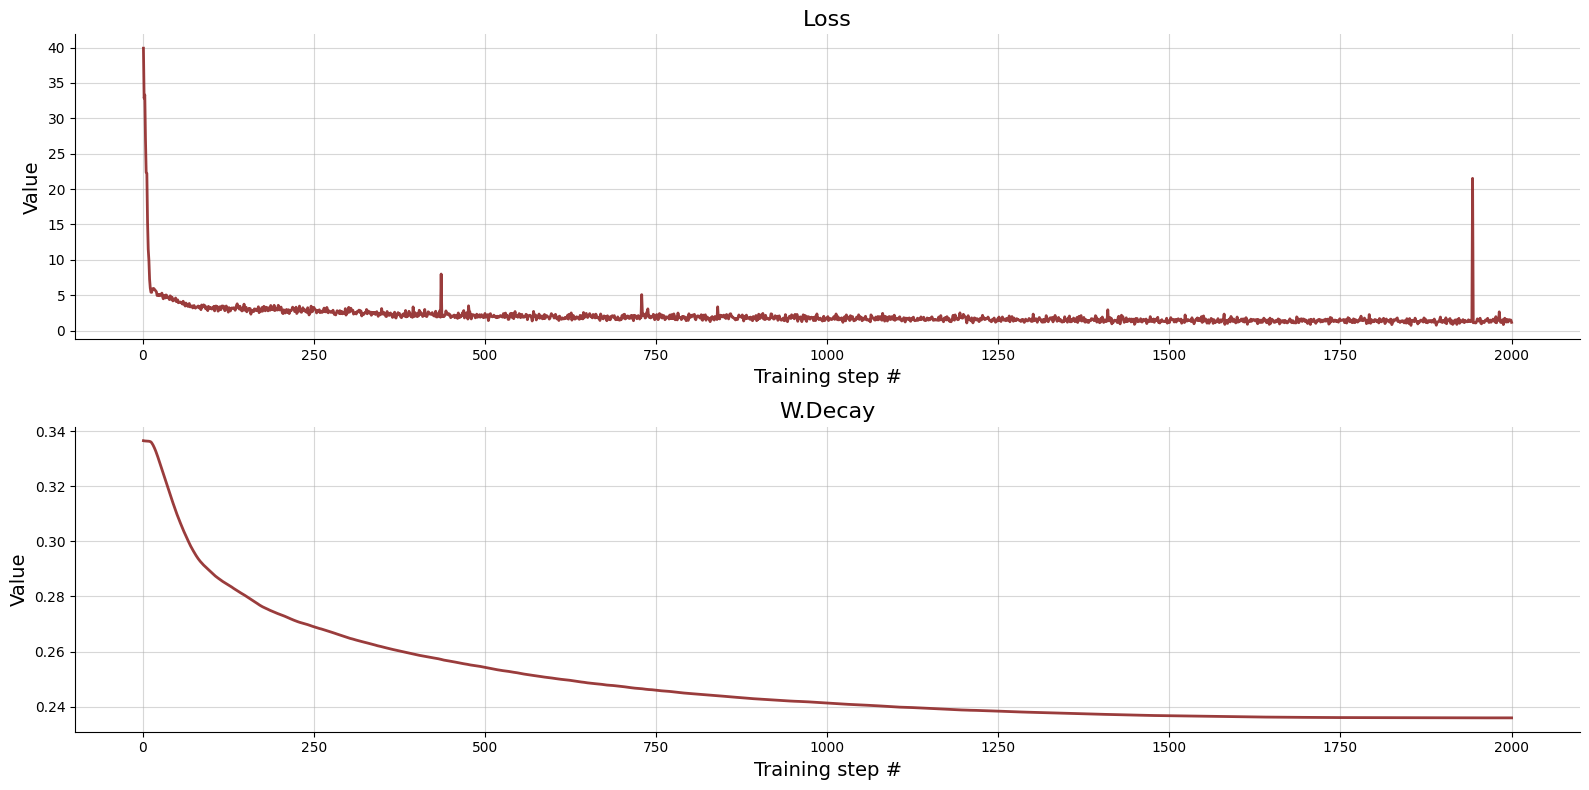

In [45]:
f = bf.diagnostics.plot_losses(train_losses=losses)

## Validation

To validate our process, we would first need to resimulate a new batch of data, and configure it for the amortizer. 

In [46]:
## Resimulation
resim = model(200)

## Configuring the resimulation
out = configurator(resim)

In [47]:
## Super extra speedy posterior sampling with the amortizer!
posterior_samples = amortizer.sample(out, n_samples=500)
posterior_samples[0]

array([[ 9.45218   ,  7.1123896 ,  0.01199633],
       [ 4.9198837 , 10.203437  ,  0.14893161],
       [ 8.018487  ,  7.807116  ,  0.0898784 ],
       ...,
       [ 6.6256022 ,  8.22691   ,  0.16178471],
       [ 5.378381  ,  9.045819  ,  0.1423415 ],
       [ 6.5220046 ,  9.298209  ,  0.19682547]], dtype=float32)

### Posterior Predictive Check

Similar to the way we inspect the prior, here we can also inspect the posterior, to see if it contracts. If it does, then we know that the parameters are learned.

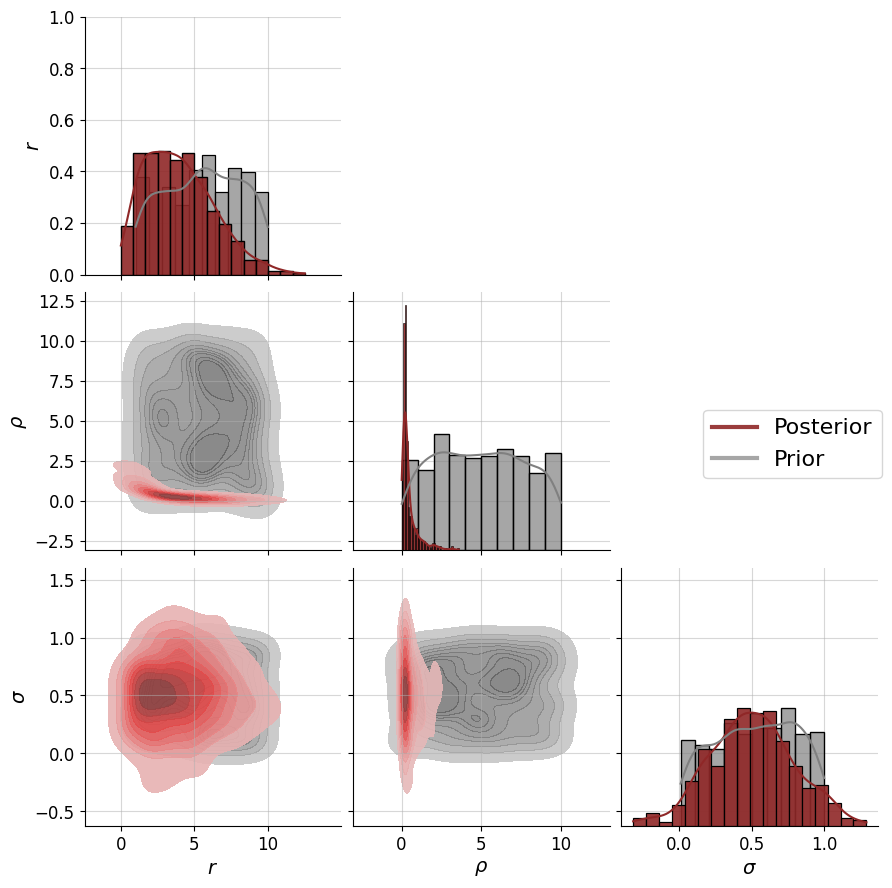

In [48]:
draws = posterior_samples[-1]
f = bf.diagnostics.plot_posterior_2d(
    posterior_draws=draws,
    prior=trainer.generative_model.prior,
    param_names=param_names
)

### Parameter Recovery

We can also visually inspect whether the model recovers the parameters of interest, even through only 2000 training steps.

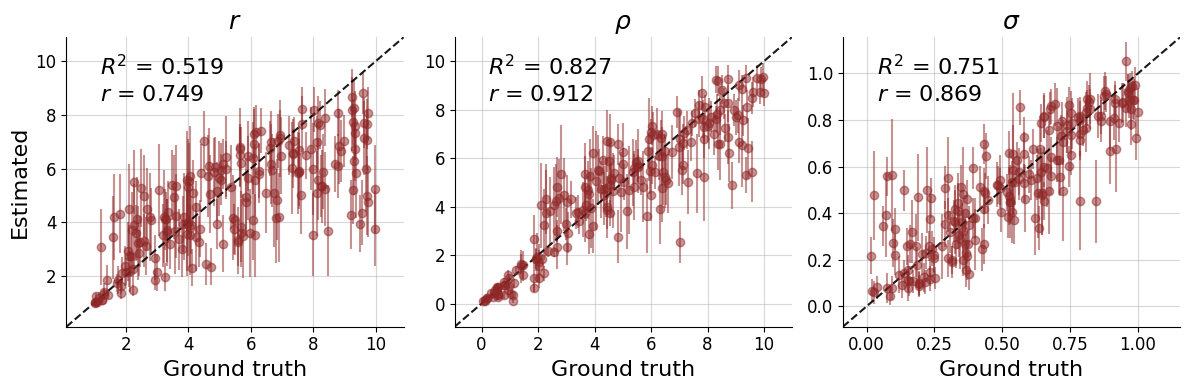

In [49]:
f = bf.diagnostics.plot_recovery(
    posterior_samples,
    out['parameters'],
    param_names=param_names
)

The parameter recovery is decent.